In [1]:
# Import necessary libraries for exploratory data analysis (EDA) and plotting
import numpy as np  # Shortened to np
import pandas as pd  # Shortened to pd
import matplotlib.pyplot as plt
import seaborn as sns  # Shortened to sns

# Ensure plots appear in the notebook
%matplotlib inline

## Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import RocCurveDisplay

# Print last updated timestamp
import time
print(f"Last updated: {time.asctime()}")

Last updated: Mon Jun  1 08:45:57 2026


In [2]:
df = pd.read_csv("/kaggle/input/datasets/dungtien1508/heartdisease-uci/heart_disease_uci.csv")
# df.shape
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


# Tiền xử lý****

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer


# Loại bỏ cột 'id' (mã bệnh nhân) và 'dataset' (tên bệnh viện nguồn)
df = df.drop(columns=['id', 'dataset'])

# =====================================================================
# STEP 2: CHUYỂN ĐỔI BIẾN MỤC TIÊU 'num' VỀ NHỊ PHÂN 'target'
# =====================================================================
# num = 0 (bình thường -> 0), num = 1,2,3,4 (bị bệnh tim -> 1)
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

# =====================================================================
# STEP 3: CHUẨN HÓA CÁC CỘT BOOLEAN (fbs, exang) CHỨA NaN
# =====================================================================
# Chuyển đổi các dạng True/False/TRUE/FALSE về 1.0 và 0.0, bảo toàn NaN
bool_mapping = {'TRUE': 1.0, 'FALSE': 0.0, True: 1.0, False: 0.0, 1: 1.0, 0: 0.0}
df['fbs'] = df['fbs'].map(bool_mapping)
df['exang'] = df['exang'].map(bool_mapping)

# =====================================================================
# STEP 4: MÃ HÓA CÁC BIẾN CATEGORICAL DẠNG CHỮ VÀ GIỮ NGUYÊN NaN
# =====================================================================
string_categorical_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
label_encoders = {}

for col in string_categorical_cols:
    # Tạo mặt nạ lọc để chỉ mã hóa các ô có dữ liệu (bỏ qua NaN)
    non_null_mask = df[col].notnull()
    le = LabelEncoder()
    
    # Ép kiểu dữ liệu về string trước khi fit để tránh lỗi định dạng
    df.loc[non_null_mask, col] = le.fit_transform(df.loc[non_null_mask, col].astype(str))
    label_encoders[col] = le

# Chuyển đổi toàn bộ bảng dữ liệu về kiểu số thực (float) để KNNImputer có thể xử lý
df = df.astype(float)

# =====================================================================
# STEP 5: TÁCH FEATURES/TARGET VÀ CHIA TẬP TRAIN/TEST (TRÁNH LEAKAGE)
# =====================================================================
X = df.drop(columns=['target'])
y = df['target'].astype(int)

# Chia tập dữ liệu 80% Train / 20% Test phân tầng theo biến mục tiêu y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================================================
# STEP 6: GÁN KHUYẾT THIẾU BẰNG KNN IMPUTER
# =====================================================================
# Fit trên tập Train, sau đó áp dụng (transform) cho cả Train và Test
imputer = KNNImputer(n_neighbors=5)
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

# =====================================================================
# STEP 7: CHUẨN HÓA THANG ĐO (SCALING) CHO CÁC BIẾN SỐ HỌC LIÊN TỤC
# =====================================================================
# Danh sách các đặc trưng định lượng cần chuẩn hóa thang đo (Chú ý tên cột 'thalch')
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

scaler = StandardScaler()
# Chỉ fit trên tập Train đã được gán khuyết thiếu để tránh rò rỉ dữ liệu
X_train_imputed[numeric_cols] = scaler.fit_transform(X_train_imputed[numeric_cols])
X_test_imputed[numeric_cols] = scaler.transform(X_test_imputed[numeric_cols])

# Chuyển đổi ngược các đặc trưng phân loại về kiểu dữ liệu số nguyên (int) cho gọn
all_cat_cols = string_categorical_cols + ['fbs', 'exang']
X_train_imputed[all_cat_cols] = X_train_imputed[all_cat_cols].round().astype(int)
X_test_imputed[all_cat_cols] = X_test_imputed[all_cat_cols].round().astype(int)

print("TIỀN XỬ LÝ DỮ LIỆU THÀNH CÔNG ")
print(f"Kích thước tập huấn luyện X_train: {X_train_imputed.shape}")
print(f"Kích thước tập kiểm thử X_test: {X_test_imputed.shape}")
print("Dữ liệu trống còn lại trong tập Train:", X_train_imputed.isnull().sum().sum())
print("Dữ liệu trống còn lại trong tập Test:", X_test_imputed.isnull().sum().sum())

TIỀN XỬ LÝ DỮ LIỆU THÀNH CÔNG 
Kích thước tập huấn luyện X_train: (736, 13)
Kích thước tập kiểm thử X_test: (184, 13)
Dữ liệu trống còn lại trong tập Train: 0
Dữ liệu trống còn lại trong tập Test: 0


In [4]:
from sklearn.model_selection import train_test_split

# Giả sử X là các feature, y là cột target
X = df.drop('target', axis=1)
y = df['target']

# Chia dữ liệu với tham số stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Đây là chìa khóa để cân bằng tỷ lệ nhãn
)

print(f"Tỷ lệ trong tập huấn luyện:\n{y_train.value_counts(normalize=True)}")
print(f"Tỷ lệ trong tập kiểm tra:\n{y_test.value_counts(normalize=True)}")

Tỷ lệ trong tập huấn luyện:
target
1.0    0.552989
0.0    0.447011
Name: proportion, dtype: float64
Tỷ lệ trong tập kiểm tra:
target
1.0    0.554348
0.0    0.445652
Name: proportion, dtype: float64


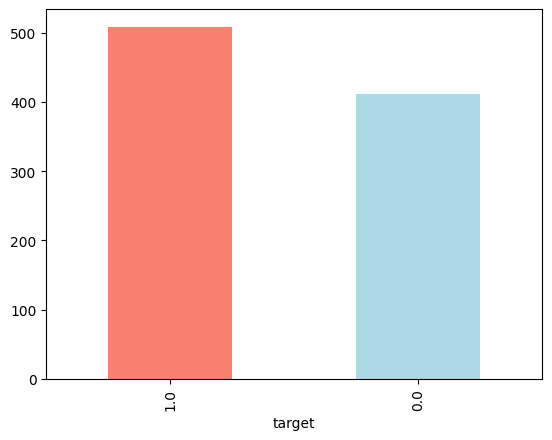

In [5]:
df.target.value_counts().plot(kind="bar", color=["salmon", "lightblue"]);

In [6]:

imputer = KNNImputer(n_neighbors=5)

# Thực hiện điền giá trị và chuyển đổi ngược lại thành DataFrame
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

df = df_imputed

# Kiểm tra lại
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    float64
 1   sex       920 non-null    float64
 2   cp        920 non-null    float64
 3   trestbps  920 non-null    float64
 4   chol      920 non-null    float64
 5   fbs       920 non-null    float64
 6   restecg   920 non-null    float64
 7   thalch    920 non-null    float64
 8   exang     920 non-null    float64
 9   oldpeak   920 non-null    float64
 10  slope     920 non-null    float64
 11  ca        920 non-null    float64
 12  thal      920 non-null    float64
 13  target    920 non-null    float64
dtypes: float64(14)
memory usage: 100.8 KB
None


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.00000,920.000000,920.000000
mean,53.510870,0.789130,0.782609,132.268261,199.308478,0.175870,0.990870,136.904783,0.393696,0.877391,1.242174,0.78087,1.408261,0.553261
std,9.424685,0.408148,0.956350,18.587226,109.268901,0.357577,0.632045,25.480291,0.477301,1.064177,0.539419,0.66740,0.506860,0.497426
min,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.00000,0.000000,0.000000
25%,47.000000,1.000000,0.000000,120.000000,176.750000,0.000000,1.000000,120.000000,0.000000,0.000000,1.000000,0.20000,1.000000,0.000000
50%,54.000000,1.000000,0.000000,130.000000,223.000000,0.000000,1.000000,138.000000,0.000000,0.560000,1.000000,0.80000,1.400000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,1.800000,1.20000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.00000,2.000000,1.000000


# GIỚI TÍNH 

In [8]:
df.sex.value_counts()

sex
1.0    726
0.0    194
Name: count, dtype: int64

In [9]:
pd.crosstab(df.target, df.sex)

sex,0.0,1.0
target,,
0.0,144,267
1.0,50,459


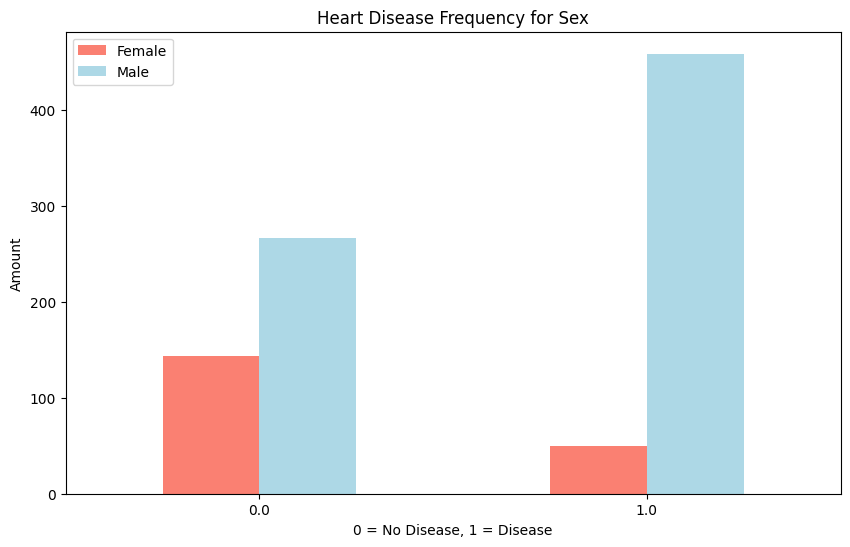

In [10]:
# Create a plot
pd.crosstab(df.target, df.sex).plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue"])

# Add some attributes to it
plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0); # keep the labels on the x-axis vertical

# TUỔI TÁC 

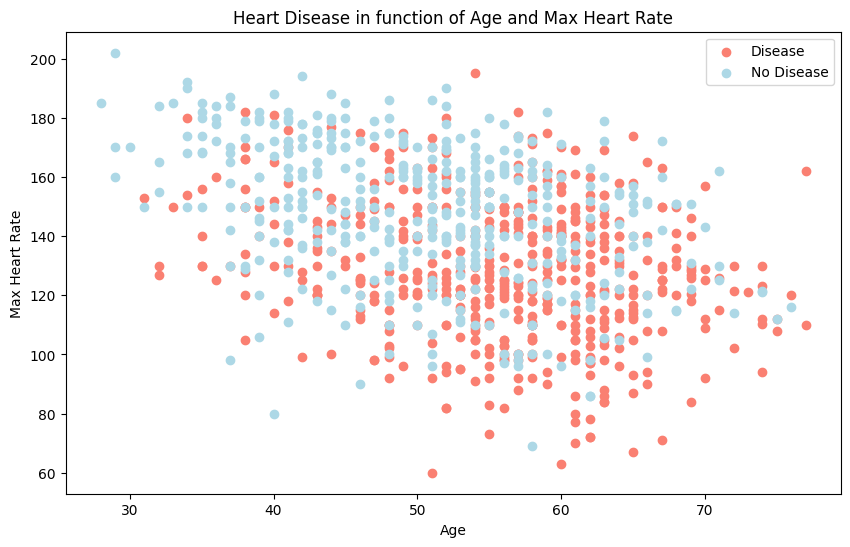

In [11]:
# Thay vì df.age, hãy dùng df['age']
# Thay vì df.thalch, hãy dùng df['thalch']

plt.figure(figsize=(10,6))

# Start with positive examples
plt.scatter(df['age'][df['target']==1], 
            df['thalch'][df['target']==1], 
            c="salmon") 

# Now for negative examples
plt.scatter(df['age'][df['target']==0], 
            df['thalch'][df['target']==0], 
            c="lightblue")

# Add some helpful info
plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.legend(["Disease", "No Disease"])
plt.ylabel("Max Heart Rate");

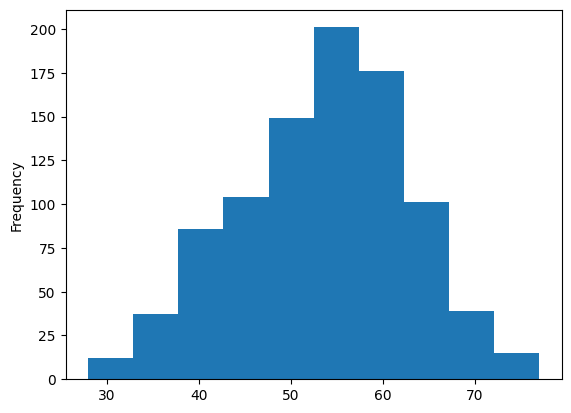

In [12]:
df.age.plot.hist();

# Đau ngực 

In [13]:
pd.crosstab(df.cp, df.target)

target,0.0,1.0
cp,,
0.0,104,392
1.0,150,24
2.0,131,73
3.0,26,20


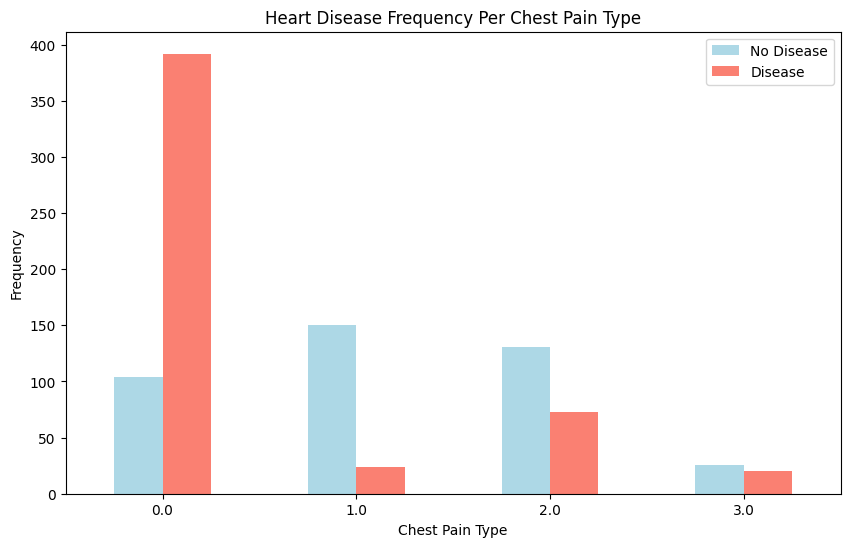

In [14]:
pd.crosstab(df.cp, df.target).plot(kind="bar",
                                   figsize=(10,6),
                                   color=["lightblue", "salmon"])

# Add attributes to the plot to make it more readable
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation = 0);

In [15]:
corr_matrix = df.corr()
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
age,1.000000,0.056889,-0.076519,0.248428,-0.088255,0.216056,-0.008021,-0.380911,0.209955,0.264929,-0.227699,0.352042,0.107542,0.282700
sex,0.056889,1.000000,-0.125933,0.002387,-0.199333,0.093338,0.072673,-0.184933,0.180847,0.100997,-0.134525,0.128184,0.150447,0.307284
cp,-0.076519,-0.125933,1.000000,-0.019671,0.066356,-0.017266,-0.069895,0.283089,-0.358196,-0.173766,0.169662,-0.195759,-0.135021,-0.385077
trestbps,0.248428,0.002387,-0.019671,1.000000,0.086783,0.129010,0.016918,-0.109954,0.152526,0.163286,-0.082856,0.057935,0.087489,0.097784
chol,-0.088255,-0.199333,0.066356,0.086783,1.000000,-0.030782,-0.198548,0.236274,-0.038289,0.045793,0.081632,-0.150664,-0.098816,-0.231782
fbs,0.216056,0.093338,-0.017266,0.129010,-0.030782,1.000000,0.052756,-0.079802,0.029966,0.039514,-0.099423,0.135582,-0.003462,0.150999
restecg,-0.008021,0.072673,-0.069895,0.016918,-0.198548,0.052756,1.000000,-0.175565,0.063148,-0.033828,-0.073808,0.030644,0.018170,0.059694
thalch,-0.380911,-0.184933,0.283089,-0.109954,0.236274,-0.079802,-0.175565,1.000000,-0.362003,-0.150114,0.420090,-0.369040,-0.203461,-0.389695
exang,0.209955,0.180847,-0.358196,0.152526,-0.038289,0.029966,0.063148,-0.362003,1.000000,0.389033,-0.325072,0.188179,0.194702,0.453772
oldpeak,0.264929,0.100997,-0.173766,0.163286,0.045793,0.039514,-0.033828,-0.150114,0.389033,1.000000,-0.378547,0.191570,0.151318,0.371425


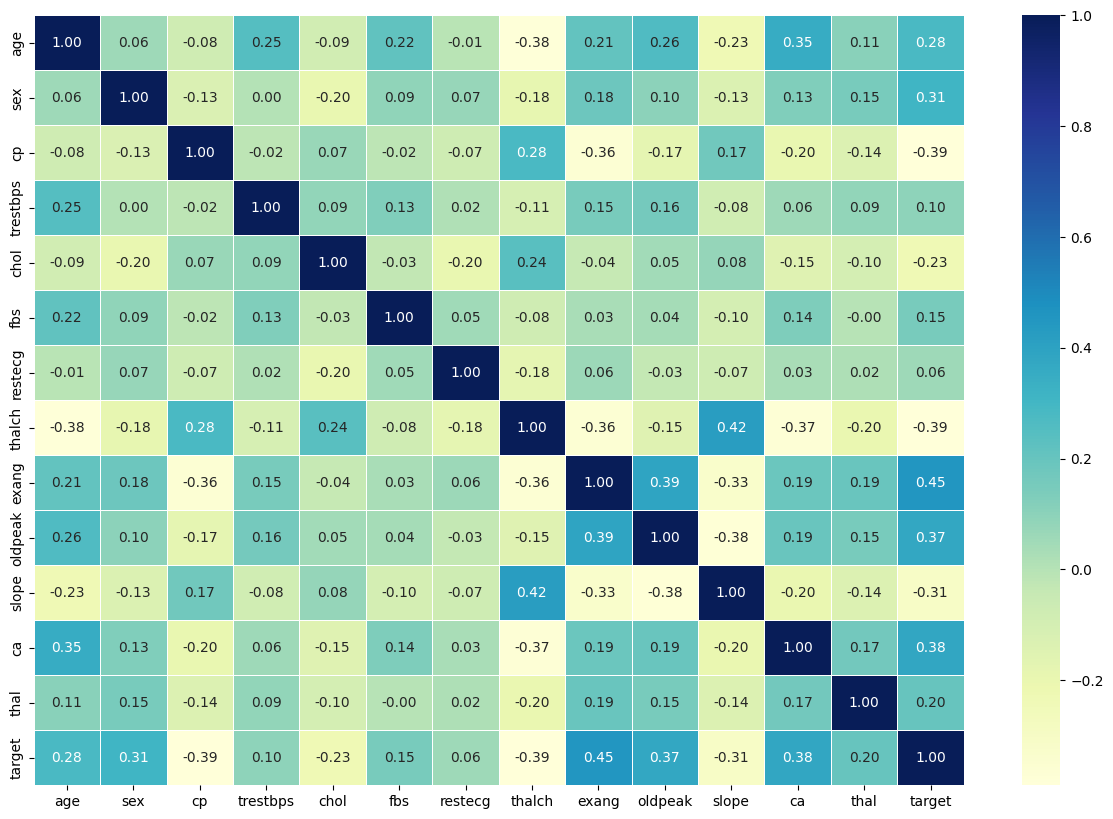

In [16]:
corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix,
            annot=True,
            linewidths=0.5,
            fmt= ".2f",
            cmap="YlGnBu");

# XÂY DỰNG MÔ HÌNH 

In [17]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,0.0,0.0
1,67.0,1.0,0.0,160.0,286.0,0.0,0.0,108.0,1.0,1.5,1.0,3.0,1.0,1.0
2,67.0,1.0,0.0,120.0,229.0,0.0,0.0,129.0,1.0,2.6,1.0,2.0,2.0,1.0
3,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,1.0,0.0
4,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,1.0,0.0


In [18]:
# Everything except target variable
X = df.drop("target", axis=1)

# Target variable
y = df.target.values

In [19]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,0.0
1,67.0,1.0,0.0,160.0,286.0,0.0,0.0,108.0,1.0,1.5,1.0,3.0,1.0
2,67.0,1.0,0.0,120.0,229.0,0.0,0.0,129.0,1.0,2.6,1.0,2.0,2.0
3,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,1.0
4,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,1.0


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Khởi tạo và huấn luyện KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_imputed, y_train)

# 2. Dự đoán và đánh giá
knn_preds = knn_model.predict(X_test_imputed)

print(" KẾT QUẢ MÔ HÌNH K-NEAREST NEIGHBORS (KNN)")
print(classification_report(y_test, knn_preds))

 KẾT QUẢ MÔ HÌNH K-NEAREST NEIGHBORS (KNN)
              precision    recall  f1-score   support

         0.0       0.83      0.82      0.82        82
         1.0       0.85      0.86      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [21]:
from sklearn.linear_model import LogisticRegression

# 1. Khởi tạo và huấn luyện Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_imputed, y_train)

# 2. Dự đoán và đánh giá
log_preds = log_model.predict(X_test_imputed)

print("KẾT QUẢ MÔ HÌNH LOGISTIC REGRESSION ")
print(classification_report(y_test, log_preds))

KẾT QUẢ MÔ HÌNH LOGISTIC REGRESSION 
              precision    recall  f1-score   support

         0.0       0.83      0.78      0.81        82
         1.0       0.83      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [22]:
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo và huấn luyện Random Forest
rf_base_model = RandomForestClassifier(random_state=42)
rf_base_model.fit(X_train_imputed, y_train)

# 2. Dự đoán và đánh giá
rf_base_preds = rf_base_model.predict(X_test_imputed)

print(" KẾT QUẢ MÔ HÌNH RANDOM FOREST")
print(classification_report(y_test, rf_base_preds))

 KẾT QUẢ MÔ HÌNH RANDOM FOREST
              precision    recall  f1-score   support

         0.0       0.86      0.82      0.84        82
         1.0       0.86      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.86       184
weighted avg       0.86      0.86      0.86       184



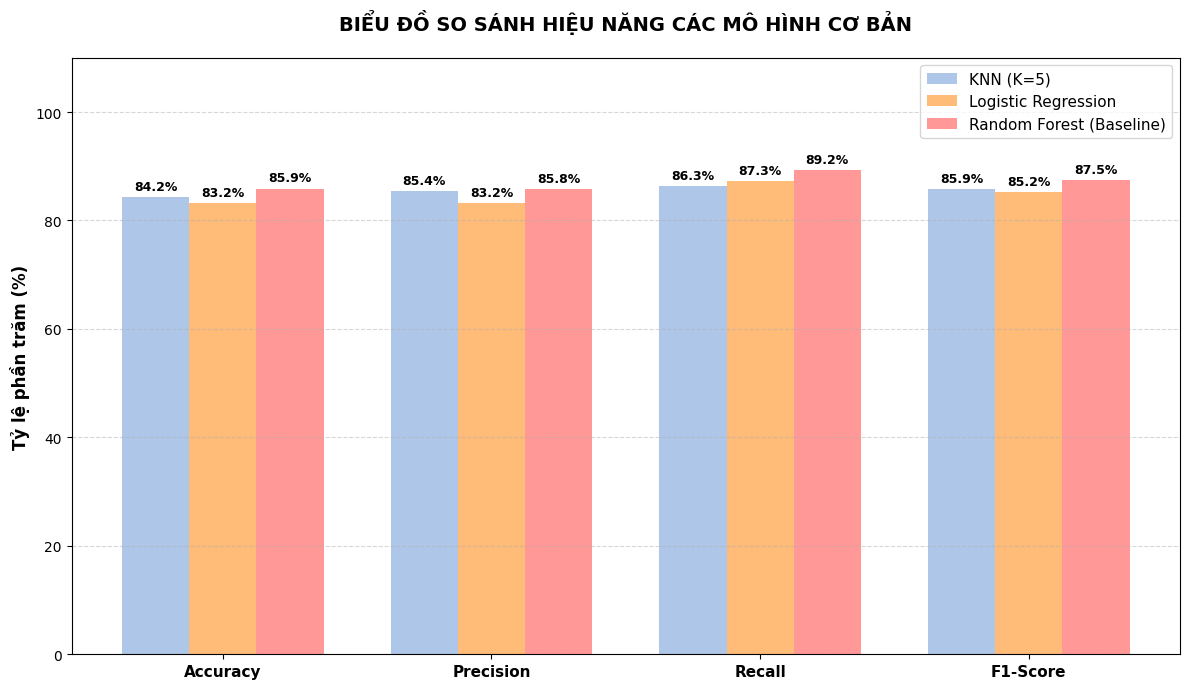

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Tự động tính toán các chỉ số đánh giá cho từng mô hình (lấy theo nhãn chính 1.0)
models_metrics = {
    'KNN': [
        accuracy_score(y_test, knn_preds),
        precision_score(y_test, knn_preds, pos_label=1.0),
        recall_score(y_test, knn_preds, pos_label=1.0),
        f1_score(y_test, knn_preds, pos_label=1.0)
    ],
    'Logistic Regression': [
        accuracy_score(y_test, log_preds),
        precision_score(y_test, log_preds, pos_label=1.0),
        recall_score(y_test, log_preds, pos_label=1.0),
        f1_score(y_test, log_preds, pos_label=1.0)
    ],
    'Random Forest (Base)': [
        accuracy_score(y_test, rf_base_preds),
        precision_score(y_test, rf_base_preds, pos_label=1.0),
        recall_score(y_test, rf_base_preds, pos_label=1.0),
        f1_score(y_test, rf_base_preds, pos_label=1.0)
    ]
}

# 2. Cấu hình các tham số hình học cho biểu đồ cột nhóm
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(labels))  # Vị trí các nhóm chỉ số trên trục hoành
width = 0.25  # Độ rộng của mỗi cột đơn

# 3. Khởi tạo khung vẽ
fig, ax = plt.subplots(figsize=(12, 7))

# Vẽ từng nhóm cột cho các mô hình kèm mã màu học thuật trực quan
rects1 = ax.bar(x - width, [m * 100 for m in models_metrics['KNN']], width, label='KNN (K=5)', color='#aec7e8')
rects2 = ax.bar(x, [m * 100 for m in models_metrics['Logistic Regression']], width, label='Logistic Regression', color='#ffbb78')
rects3 = ax.bar(x + width, [m * 100 for m in models_metrics['Random Forest (Base)']], width, label='Random Forest (Baseline)', color='#ff9896')

# 4. Định dạng thẩm mỹ và chú thích cho biểu đồ
ax.set_ylabel('Tỷ lệ phần trăm (%)', fontsize=12, fontweight='bold')
ax.set_title('BIỂU ĐỒ SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH CƠ BẢN', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax.set_ylim(0, 110)  # Để chừa không gian phía trên hiển thị nhãn số
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hàm tự động hiển thị giá trị số chính xác lên đỉnh mỗi cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # Đẩy chữ lên phía trên cột 3 points
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

# DÙNG GridSearchCV cho Random Forest 

In [24]:
from sklearn.model_selection import RandomizedSearchCV

# Xác định không gian tham số
param_dist = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

# Chạy random search (thử 20 tổ hợp ngẫu nhiên)
rs = RandomizedSearchCV(rf, param_distributions=param_dist, n_iter=20, cv=5, verbose=1, random_state=42)
rs.fit(X_train_imputed, y_train)

print(f"Tham số tốt nhất tìm được: {rs.best_params_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Tham số tốt nhất tìm được: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}


In [25]:
from sklearn.model_selection import GridSearchCV

# Dựa vào kết quả trước, ta quét tập trung hơn
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [None, 5],
    'min_samples_split': [4, 5, 6],
    'min_samples_leaf': [1, 2, 3]
}

rf = RandomForestClassifier(random_state=42)

# Chạy Grid Search
gs = GridSearchCV(rf, param_grid=param_grid, cv=5, verbose=1)
gs.fit(X_train_imputed, y_train)

print(f"Tham số tốt nhất sau khi Grid Search: {gs.best_params_}")
print(f"Độ chính xác tốt nhất: {gs.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Tham số tốt nhất sau khi Grid Search: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 150}
Độ chính xác tốt nhất: 0.8315


In [26]:
from sklearn.metrics import accuracy_score

final_model = gs.best_estimator_

# Dự đoán trên tập Test
y_pred_final = final_model.predict(X_test_imputed)

# So sánh với kết quả tốt nhất cũ (của RandomizedSearchCV)
print("Độ chính xác trên tập Test thực tế:", accuracy_score(y_test, y_pred_final))

Độ chính xác trên tập Test thực tế: 0.8532608695652174


# Dùng GridSearchCV cho KNN 

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# 1. Xác định không gian tham số cho KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 19, 21], # Thử các giá trị k lẻ
    'weights': ['uniform', 'distance'],          # Cách đánh trọng số
    'metric': ['euclidean', 'manhattan']         # Cách đo khoảng cách
}

# 2. Khởi tạo mô hình
knn = KNeighborsClassifier()

# 3. Chạy GridSearchCV
knn_gs = GridSearchCV(knn, param_grid=knn_param_grid, cv=5, verbose=1)

knn_gs.fit(X_train_imputed, y_train)

# 4. In kết quả tốt nhất
print(f"Tham số KNN tốt nhất tìm được: {knn_gs.best_params_}")

# 5. Đánh giá trên tập Test thực tế
knn_best_model = knn_gs.best_estimator_
knn_test_score = knn_best_model.score(X_test_imputed, y_test)

print(f"Độ chính xác của KNN trên tập Test: {knn_test_score:.4f}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Tham số KNN tốt nhất tìm được: {'metric': 'manhattan', 'n_neighbors': 19, 'weights': 'distance'}
Độ chính xác của KNN trên tập Test: 0.8478


# ĐÁNH GIÁ 

In [28]:
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo lại mô hình với bộ tham số tốt nhất bạn đã tìm được
best_rf = RandomForestClassifier(n_estimators=200, 
                                 min_samples_split=5, 
                                 min_samples_leaf=2, 
                                 max_depth=None, 
                                 random_state=42)

# 2. Huấn luyện lại mô hình
best_rf.fit(X_train_imputed, y_train)

# 3. Thực hiện dự đoán
y_preds = best_rf.predict(X_test_imputed)

# In thử 10 kết quả dự đoán đầu tiên để kiểm tra
print("10 dự đoán đầu tiên:", y_preds[:10])

10 dự đoán đầu tiên: [0. 1. 1. 1. 1. 1. 0. 1. 0. 1.]


In [29]:
y_test

514    1.0
825    1.0
854    1.0
804    1.0
887    0.0
      ... 
59     0.0
815    1.0
631    1.0
740    1.0
282    1.0
Name: target, Length: 184, dtype: float64

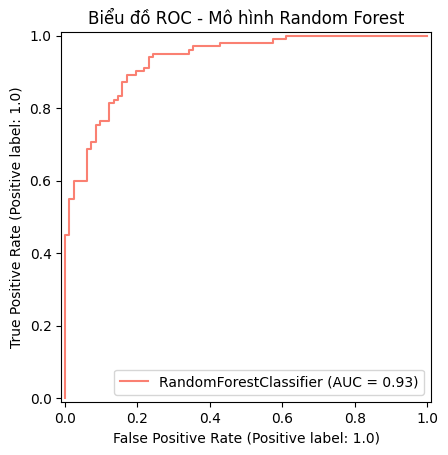

In [30]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Sử dụng mô hình Random Forest tốt nhất của bạn (best_rf)
# và tập dữ liệu Test đã qua xử lý (X_test_imputed)
RocCurveDisplay.from_estimator(estimator=best_rf, 
                               X=X_test_imputed, 
                               y=y_test,
                               color="salmon") # Thêm chút màu cho đẹp

# Thêm tiêu đề cho biểu đồ
plt.title("Biểu đồ ROC - Mô hình Random Forest")
plt.show()

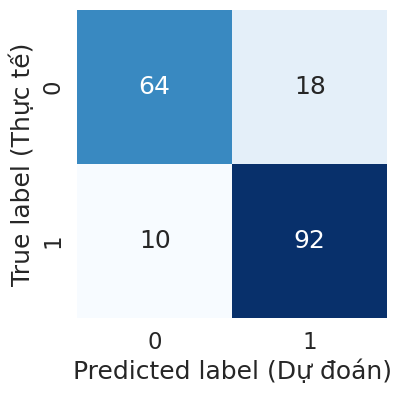

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.set(font_scale=1.5)

def plot_conf_mat(y_test, y_preds):
    """
    Plots a confusion matrix using Seaborn's heatmap().
    """
    fig, ax = plt.subplots(figsize=(4, 4)) # Chỉnh to lên một xíu để chữ không bị chèn
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, 
                     cbar=False,
                     cmap="Blues") 
    
    # ĐÃ SỬA LẠI NHÃN Ở ĐÂY
    plt.ylabel("True label (Thực tế)")
    plt.xlabel("Predicted label (Dự đoán)")
    plt.show()

plot_conf_mat(y_test, y_preds)

In [32]:
from sklearn.metrics import classification_report

# In báo cáo phân loại chi tiết
print(" BÁO CÁO TỔNG KẾT MÔ HÌNH RANDOM FOREST ")
print(classification_report(y_test, y_preds))

 BÁO CÁO TỔNG KẾT MÔ HÌNH RANDOM FOREST 
              precision    recall  f1-score   support

         0.0       0.86      0.78      0.82        82
         1.0       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



# Kiểm ĐỊNH CHÉO 

In [33]:
from sklearn.model_selection import cross_val_score

# 1. Tính Accuracy qua 5-fold cross-validation
cv_acc = cross_val_score(best_rf, X_train_imputed, y_train, cv=5, scoring="accuracy")
cv_acc_mean = cv_acc.mean()

print("--- CROSS-VALIDATED ACCURACY ---")
print("Accuracy của từng fold:", cv_acc)
print(f"Accuracy trung bình: {cv_acc_mean:.4f}")

--- CROSS-VALIDATED ACCURACY ---
Accuracy của từng fold: [0.82432432 0.8707483  0.81632653 0.81632653 0.80952381]
Accuracy trung bình: 0.8274


In [34]:
# 2. Tính Precision qua 5-fold cross-validation
cv_precision = cross_val_score(best_rf, X_train_imputed, y_train, cv=5, scoring="precision")
cv_precision_mean = cv_precision.mean()

print("--- CROSS-VALIDATED PRECISION ---")
print("Precision của từng fold:", cv_precision)
print(f"Precision trung bình: {cv_precision_mean:.4f}")

--- CROSS-VALIDATED PRECISION ---
Precision của từng fold: [0.81818182 0.88888889 0.82926829 0.82926829 0.81927711]
Precision trung bình: 0.8370


In [35]:
# 3. Tính Recall qua 5-fold cross-validation
cv_recall = cross_val_score(best_rf, X_train_imputed, y_train, cv=5, scoring="recall")
cv_recall_mean = cv_recall.mean()

print("--- CROSS-VALIDATED RECALL ---")
print("Recall của từng fold:", cv_recall)
print(f"Recall trung bình: {cv_recall_mean:.4f}")

--- CROSS-VALIDATED RECALL ---
Recall của từng fold: [0.87804878 0.87804878 0.83950617 0.83950617 0.83950617]
Recall trung bình: 0.8549


In [36]:
# 4. Tính F1-score qua 5-fold cross-validation
cv_f1 = cross_val_score(best_rf, X_train_imputed, y_train, cv=5, scoring="f1")
cv_f1_mean = cv_f1.mean()

print("--- CROSS-VALIDATED F1-SCORE ---")
print("F1-score của từng fold:", cv_f1)
print(f"F1-score trung bình: {cv_f1_mean:.4f}")

--- CROSS-VALIDATED F1-SCORE ---
F1-score của từng fold: [0.84705882 0.88343558 0.83435583 0.83435583 0.82926829]
F1-score trung bình: 0.8457


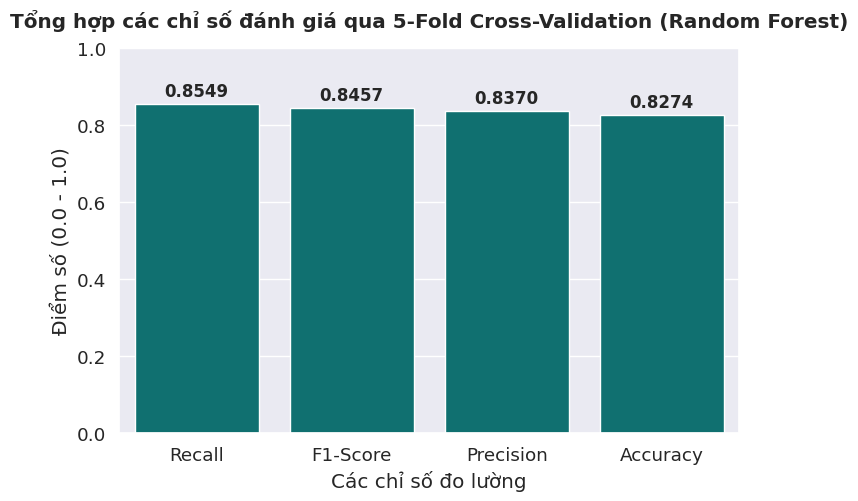

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập font size cho biểu đồ rõ ràng hơn
sns.set(font_scale=1.2)

# Gom các giá trị trung bình vào một DataFrame
cv_metrics = pd.DataFrame({
    "Chỉ số": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Điểm số": [cv_acc_mean, cv_precision_mean, cv_recall_mean, cv_f1_mean]
})

# Sắp xếp các chỉ số từ cao đến thấp để biểu đồ gọn gàng hơn
cv_metrics = cv_metrics.sort_values(by="Điểm số", ascending=False)

# Khởi tạo khung vẽ
fig, ax = plt.subplots(figsize=(8, 5))

# ĐÃ SỬA: Dùng tham số color="teal" thay vì palette để tô một màu đồng nhất và không bị lỗi phiên bản
sns.barplot(x="Chỉ số", y="Điểm số", data=cv_metrics, color="teal", ax=ax)

# Hiển thị giá trị số chính xác lên đỉnh của từng cột
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=12,
                weight='bold')

# Cấu hình tiêu đề và giới hạn trục
plt.title("Tổng hợp các chỉ số đánh giá qua 5-Fold Cross-Validation (Random Forest)", weight='bold', pad=15)
plt.ylim(0, 1.0) 
plt.ylabel("Điểm số (0.0 - 1.0)")
plt.xlabel("Các chỉ số đo lường")

plt.show()

# HỆ SỐ ĐẶC TRƯNG 

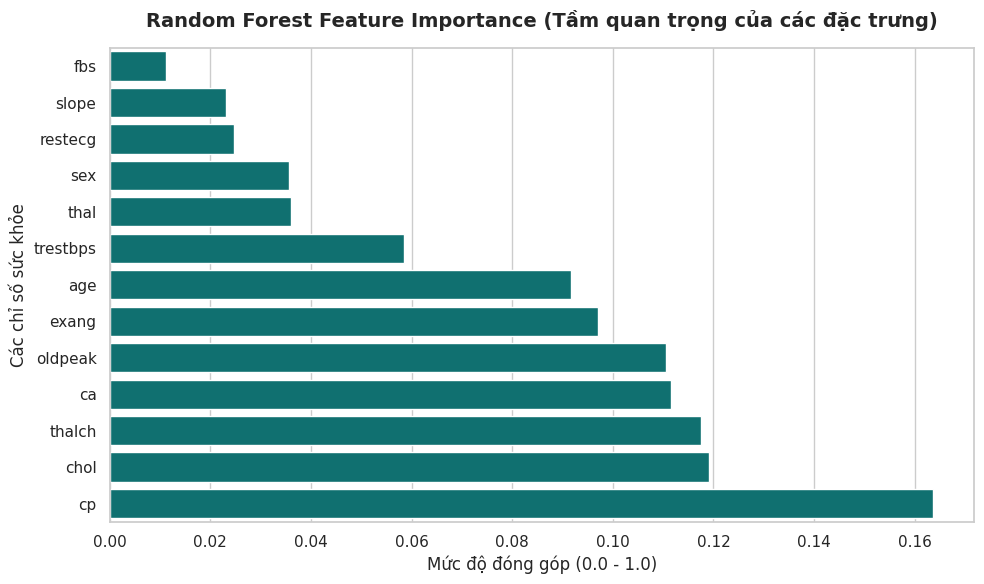

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lấy độ quan trọng của các đặc trưng từ mô hình Random Forest
# Thay vì .coef_[0], Random Forest dùng trực tiếp .feature_importances_
feature_importances = best_rf.feature_importances_

# 2. Tạo một DataFrame để quản lý (loại bỏ cột mục tiêu 'target' nếu df của bạn vẫn chứa nó)
# Giả sử các cột đặc trưng trùng với thứ tự cột trong df (trừ cột target)
feature_cols = [col for col in df.columns if col != 'target'] 

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': feature_importances
})

# 3. Sắp xếp các đặc trưng từ cao đến thấp để biểu đồ đẹp và dễ đọc hơn
importance_df = importance_df.sort_values(by='Importance', ascending=True)

# 4. Trực quan hóa bằng biểu đồ thanh ngang (Ngang sẽ dễ đọc tên biến hơn đứng)
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Vẽ biểu đồ với màu sắc đồng bộ (Teal) giống biểu đồ trước của bạn
sns.barplot(x='Importance', y='Feature', data=importance_df, color='teal')

# Thêm tiêu đề và nhãn
plt.title('Random Forest Feature Importance (Tầm quan trọng của các đặc trưng)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Mức độ đóng góp (0.0 - 1.0)', fontsize=12)
plt.ylabel('Các chỉ số sức khỏe', fontsize=12)

plt.tight_layout()
plt.show()

# Thử nghiệm nâng cao

In [39]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

In [40]:
# Khởi tạo mô hình XGBoost
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)

# Huấn luyện mô hình
xgb_model.fit(X_train_imputed, y_train)

# Dự đoán và in kết quả
xgb_preds = xgb_model.predict(X_test_imputed)
print("--- KẾT QUẢ XGBOOST ---")
print(f"Accuracy trên tập Test: {accuracy_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds))

--- KẾT QUẢ XGBOOST ---
Accuracy trên tập Test: 0.8207
              precision    recall  f1-score   support

         0.0       0.83      0.76      0.79        82
         1.0       0.82      0.87      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.82       184
weighted avg       0.82      0.82      0.82       184



In [41]:
# Khởi tạo mô hình CatBoost (verbose=0 để ẩn các dòng log huấn luyện dài dòng)
cat_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=6, random_seed=42, verbose=0)

# Huấn luyện mô hình
cat_model.fit(X_train_imputed, y_train)

# Dự đoán và in kết quả
cat_preds = cat_model.predict(X_test_imputed)
print("--- KẾT QUẢ CATBOOST ---")
print(f"Accuracy trên tập Test: {accuracy_score(y_test, cat_preds):.4f}")
print(classification_report(y_test, cat_preds))

--- KẾT QUẢ CATBOOST ---
Accuracy trên tập Test: 0.8315
              precision    recall  f1-score   support

         0.0       0.82      0.79      0.81        82
         1.0       0.84      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



# Thử nghiệm mô hình

In [42]:
import joblib

# 1. Lưu mô hình Random Forest tốt nhất
joblib.dump(best_rf, 'heart_disease_random_forest_model.pkl')

# 2. Lưu luôn cả StandardScaler và KNNImputer của bạn (RẤT QUAN TRỌNG)
# Vì khi có bệnh nhân mới, dữ liệu của họ cũng phải được điền khuyết và chuẩn hóa y hệt tập train
# Giả sử ở bước tiền xử lý bạn đặt tên biến scaler là 'scaler' và imputer là 'imputer'
# joblib.dump(scaler, 'scaler.pkl')
# joblib.dump(imputer, 'imputer.pkl')

print("XUẤT FILE MÔ HÌNH THÀNH CÔNG!")

XUẤT FILE MÔ HÌNH THÀNH CÔNG!


In [43]:
import numpy as np

def predict_new_patient(patient_data):
    """
    Hàm nhận vào mảng đặc trưng của 1 bệnh nhân mới, 
    tiền xử lý (nếu có) và đưa ra dự đoán.
    """
    # Chuyển dữ liệu về dạng mảng 2D (1, số_đặc_trưng)
    data_array = np.array(patient_data).reshape(1, -1)
    

    prediction = best_rf.predict(data_array)
    prediction_proba = best_rf.predict_proba(data_array)
    
    if prediction[0] == 1:
        print(f"⚠️ CẢNH BÁO: Bệnh nhân có nguy cơ mắc bệnh tim cao! (Xác suất: {prediction_proba[0][1]*100:.2f}%)")
    else:
        print(f"✅ AN TÂM: Bệnh nhân có hệ tim khỏe mạnh. (Xác suất an toàn: {prediction_proba[0][0]*100:.2f}%)")


test_patient = X_test_imputed.values[0] 
predict_new_patient(test_patient)

✅ AN TÂM: Bệnh nhân có hệ tim khỏe mạnh. (Xác suất an toàn: 54.17%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
